In [1]:
!pip install -q transformers accelerate bitsandbytes scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00


In [19]:
!pip install -U bitsandbytes>=0.46.1

In [1]:
import json
import torch
import re
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [2]:
from huggingface_hub import login
login()

In [3]:
data = []
with open("/content/val.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

print("Sample:", data[0])


Sample: {'text': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nYou are a legal risk analyst specializing in licensing agreements. Your task is to analyze a contract clause and assess its risk level from a specific party\'s perspective. Focus on the practical consequences for the party — what they stand to lose, what obligations they must perform, and how protected they are if things go wrong. As a rough guide: low risk implies little to no liability for the party, and high risk implies exposure.<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nAnalyze the following contract clause from the perspective of the **Licensor**.\n\nClause:\n"""\nSTRICT LIABILITY, EVEN IF THAT PARTY HAS BEEN PLACED ON NOTICE OF THE POSSIBILITY OF SUCH DAMAGES. FOR CLARITY AND NOTWITHSTANDING THE PROVISIONS OF THE FIRST SENTENCE OF THIS SECTION 13.5, ROYALTIES AND MILESTONES PAYABLE TO CYTODYN IN CONNECTION WITH VYERA’S COMMERCIALIZATION OF LICENSED PRODUCTS IN ACCORDANCE WITH THE TERMS OF

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=bnb_config
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [5]:
def clean_input(text):
    # Remove existing assistant response
    return text.split("<|start_header_id|>assistant<|end_header_id|>")[0] + "<|start_header_id|>assistant<|end_header_id|>\n\n"

In [6]:
def generate_response(text):
    prompt = clean_input(text)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            temperature=0.0
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [7]:
def extract_label(text):
    text = text.upper()

    # Prefer explicit format
    match = re.search(r'RISK LEVEL\s*:\s*(HIGH|LOW)', text)
    if match:
        return match.group(1)

    # fallback
    match = re.search(r'\b(HIGH|LOW)\b', text)
    return match.group(1) if match else "UNKNOWN"

In [8]:
results = []

for example in tqdm(data):
    output = generate_response(example["text"])
    pred = extract_label(output)

    results.append({
        "true": example["_meta"]["risk"].upper(),
        "pred": pred,
        "raw_output": output
    })

  0%|          | 0/826 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|██████████| 826/826 [1:13:41<00:00,  5.35s/it]


In [9]:
y_true = []
y_pred = []

for r in results:
    if r["pred"] == "UNKNOWN":
        continue

    y_true.append(r["true"])
    y_pred.append(r["pred"])

print("Evaluated samples:", len(y_true))

Evaluated samples: 826


In [10]:
labels = ["LOW", "HIGH"]

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, digits=4))

Accuracy: 0.6440677966101694

Classification Report:

              precision    recall  f1-score   support

         LOW     0.7663    0.7303    0.7479       597
        HIGH     0.3735    0.4192    0.3951       229

    accuracy                         0.6441       826
   macro avg     0.5699    0.5748    0.5715       826
weighted avg     0.6574    0.6441    0.6500       826



In [11]:
cm = confusion_matrix(y_true, y_pred, labels=labels)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[436 161]
 [133  96]]


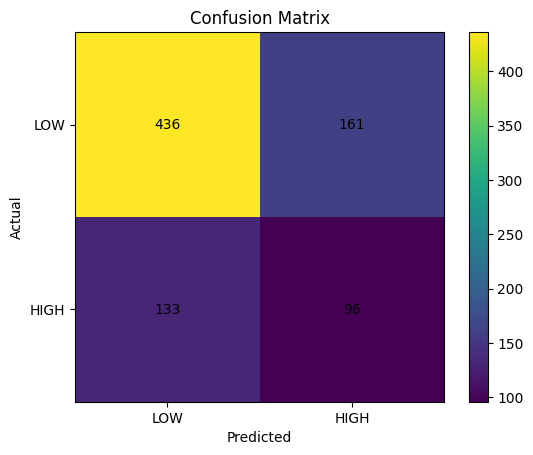

In [12]:
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()